# Project 13 -- Anthony Micco

**TA Help:** None

**Collaboration:** None

**Internet Resources:** 
- https://geopandas.org/en/stable/docs/user_guide/mapping.html (Used to help plot chloropleth maps)
- https://matplotlib.org/stable/users/explain/colors/colormaps.html (Used to change color of chloropleth maps)
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html (Used to better understand how to merge two dataframes together)

**ChatGPT, Gemini, Claude, etc:** None

**Link to AI Chat History**: None

**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [54]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
#reading in the data
df = pd.read_csv('/anvil/projects/tdm/data/fars/2021/accident.csv', encoding='latin1')

In [56]:
#printing the shape of the data
df.shape

(39508, 80)

In [57]:
#printing the head of the data
df.head()

,STATE,STATENAME,ST_CASE,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS,PVH_INVL,PERSONS,PERMVIT,...,NOT_MINNAME,ARR_HOUR,ARR_HOURNAME,ARR_MIN,ARR_MINNAME,HOSP_HR,HOSP_HRNAME,HOSP_MN,HOSP_MNNAME,FATALS
0,1,Alabama,10001,0,0,2,2,0,3,3,...,13,22,10:00pm-10:59pm,25,25,23,11:00pm-11:59pm,2,2,2
1,1,Alabama,10002,0,0,1,1,0,2,2,...,Unknown,19,7:00pm-7:59pm,9,9,88,Not Applicable (Not Transported),88,Not Applicable (Not Transported),2
2,1,Alabama,10003,1,1,1,1,0,1,1,...,29,9,9:00am-9:59am,40,40,88,Not Applicable (Not Transported),88,Not Applicable (Not Transported),1
3,1,Alabama,10004,0,0,1,1,0,1,1,...,20,16,4:00pm-4:59pm,28,28,99,Unknown,99,Unknown EMS Hospital Arrival Time,1
4,1,Alabama,10005,0,0,2,2,0,4,4,...,20,22,10:00pm-10:59pm,30,30,88,Not Applicable (Not Transported),88,Not Applicable (Not Transported),1


In [58]:
#checking for missing data in all columns
df.isna().sum()

STATE          0
STATENAME      0
ST_CASE        0
PEDS           0
PERNOTMVIT     0
              ..
HOSP_HR        0
HOSP_HRNAME    0
HOSP_MN        0
HOSP_MNNAME    0
FATALS         0
Length: 80, dtype: int64

In [59]:
#checking the value counts of the lat/longs
print(df['LATITUDE'].value_counts().sort_index())
print(df['LONGITUD'].value_counts().sort_index())

LATITUDE
19.060325     1
19.082319     1
19.196472     1
19.294000     1
19.425025     1
             ..
65.500278     1
66.897883     1
77.777700    79
88.888800    12
99.999900    44
Name: count, Length: 39169, dtype: int64
LONGITUD
-162.594406     1
-161.899131     1
-161.779986     1
-159.341614     1
-159.338922     1
               ..
-67.245550      1
-67.231300      1
 777.777700    79
 888.888800    12
 999.999900    44
Name: count, Length: 39239, dtype: int64


In [60]:
#determining the number of invalid latitude and longitude values

# Determine invalid latitude values
no_lat = (df['LATITUDE'] == 77.7777) | (df['LATITUDE'] == 88.8888) | (df['LATITUDE'] == 99.9999)

# Determine invalid longitude values
no_long = (df['LONGITUD'] == 777.7777) | (df['LONGITUD'] == 888.8888) | (df['LONGITUD'] == 999.9999)

print(f"\nNumber of missing/unknown latitude: {no_lat.sum()}")
print(f"Number of missing/unknown longitude: {no_long.sum()}")
print(f"Normal coordinates: {len(df)-no_lat.sum()}")


Number of missing/unknown latitude: 135
Number of missing/unknown longitude: 135
Normal coordinates: 39373


In [61]:
#removing the invalid coordinates from the dataset
df_clean = df[~no_lat & ~no_long].copy()

In [62]:
#print the shape of the cleaned dataset
df_clean.shape

(39373, 80)

In [63]:
#finding the range of latitude and longitudes
# Range of values latitdue in this dataset take on
print(f"Latitude Range: {df_clean["LATITUDE"].min()} to {df_clean["LATITUDE"].max()}")
# Range of values longitude in this dataset take on
print(f"Longitude Range: {df_clean['LONGITUD'].min()} to {df_clean['LONGITUD'].max()}")

Latitude Range: 19.060325 to 66.89788333
Longitude Range: -162.59440556 to -67.2313


In [64]:
#finding the number of crashes by state
print(df.groupby('STATENAME')['FATALS'].sum().sort_values(ascending=False))

STATENAME
Texas                   4498
California              4285
Florida                 3738
Georgia                 1797
North Carolina          1663
Ohio                    1354
Illinois                1334
Tennessee               1327
Pennsylvania            1230
South Carolina          1198
Arizona                 1180
New York                1157
Michigan                1136
Missouri                1016
Alabama                  983
Virginia                 973
Louisiana                972
Indiana                  932
Kentucky                 806
Mississippi              772
Oklahoma                 762
New Jersey               699
Arkansas                 693
Colorado                 691
Washington               670
Wisconsin                620
Oregon                   599
Maryland                 561
Minnesota                488
New Mexico               481
Kansas                   424
Massachusetts            417
Nevada                   385
Iowa                     356
Utah

In [65]:
#viewing individual crash instances 
print(df[['STATENAME', 'LATITUDE', 'LONGITUD', 'FATALS']])

      STATENAME   LATITUDE    LONGITUD  FATALS
0       Alabama  33.601642  -86.312383       2
1       Alabama  33.541361  -86.643744       2
2       Alabama  33.419797  -86.752572       1
3       Alabama  33.360894  -86.777139       1
4       Alabama  33.815208  -86.825342       1
...         ...        ...         ...     ...
39503   Wyoming  44.183594 -106.622031       1
39504   Wyoming  44.257797 -107.856219       1
39505   Wyoming  41.560719 -109.536278       1
39506   Wyoming  41.138878 -104.766653       1
39507   Wyoming  42.997253 -111.012300       1

[39508 rows x 4 columns]


## Question 2

In [66]:
#imports
import geopandas as gpd

In [67]:
#creating new geopandas dataframe
geo_df = gpd.GeoDataFrame(df_clean, geometry=gpd.points_from_xy(df_clean['LONGITUD'], df_clean['LATITUDE']), crs='EPSG:4326')

In [68]:
#printing the type of the geopandas dataframe
type(geo_df)

geopandas.geodataframe.GeoDataFrame

In [69]:
geo_df[['STATENAME', 'FATALS', 'LATITUDE', 'LONGITUD', 'geometry']].head()

,STATENAME,FATALS,LATITUDE,LONGITUD,geometry
0,Alabama,2,33.601642,-86.312383,POINT (-86.31238 33.60164)
1,Alabama,2,33.541361,-86.643744,POINT (-86.64374 33.54136)
2,Alabama,1,33.419797,-86.752572,POINT (-86.75257 33.4198)
3,Alabama,1,33.360894,-86.777139,POINT (-86.77714 33.36089)
4,Alabama,1,33.815208,-86.825342,POINT (-86.82534 33.81521)


In [70]:
#loading in state boundary polygon data
states_gdf = gpd.read_file('/anvil/projects/tdm/data/tiger/state/tl_2021_us_state.zip')

In [71]:
# viewing the contents of the zip file
import zipfile

zf = zipfile.ZipFile('/anvil/projects/tdm/data/tiger/state/tl_2021_us_state.zip', 'r')
print(zf.namelist())
zf.close()

['tl_2021_us_state.cpg', 'tl_2021_us_state.dbf', 'tl_2021_us_state.prj', 'tl_2021_us_state.shp', 'tl_2021_us_state.shp.ea.iso.xml', 'tl_2021_us_state.shp.iso.xml', 'tl_2021_us_state.shx']


In [72]:
#printing the head and shape of the states_gdf dataframe
# Shape
print(f"states_gdf shape: {states_gdf.shape}")

states_gdf shape: (56, 15)


In [73]:
# Head
states_gdf.head()

,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,3,5,54,01779805,54,WV,West Virginia,00,G4000,A,62266298634,489204185,+38.6472854,-080.6183274,"POLYGON ((-80.85847 37.42831, -80.85856 37.428..."
1,3,5,12,00294478,12,FL,Florida,00,G4000,A,138961722096,45972570361,+28.3989775,-082.5143005,"MULTIPOLYGON (((-83.10874 24.62949, -83.10711 ..."
2,2,3,17,01779784,17,IL,Illinois,00,G4000,A,143778561906,6216493488,+40.1028754,-089.1526108,"POLYGON ((-89.17208 37.06831, -89.17296 37.067..."
3,2,4,27,00662849,27,MN,Minnesota,00,G4000,A,206232627084,18949394733,+46.3159573,-094.1996043,"POLYGON ((-92.74568 45.29604, -92.74629 45.295..."
4,3,5,24,01714934,24,MD,Maryland,00,G4000,A,25151992308,6979074857,+38.9466584,-076.6744939,"POLYGON ((-75.76659 39.37756, -75.7663 39.3738..."


In [74]:
#printing the CRS of states_gdf
print(states_gdf.crs)

EPSG:4269


In [75]:
#prinint the CRS of geo_df
print(geo_df.crs)

EPSG:4326


In [76]:
#changing states_gdf crs to the global standard WGS 84
states_gdf = states_gdf.to_crs('EPSG:4326')

In [77]:
#printing the new states_gdf crs
print(f"New states_gdf crs: {states_gdf.crs}")

New states_gdf crs: EPSG:4326


In [78]:
#examining the bounding box of only Ohio
ohio = states_gdf[states_gdf['NAME'] == 'Ohio'].iloc[0]
# Print state name
print(f"State: {ohio['NAME']}") 
# Print geometry type
print(f"Geometry type: {ohio.geometry.geom_type}")
# Print bounding box
print(f"Bounding box: {ohio.geometry.bounds}")

State: Ohio
Geometry type: Polygon
Bounding box: (-84.820305, 38.403423, -80.518705, 42.327132)


In [79]:
#finding the number of coordinates at the border
print(f"Number of coordinates of Ohio border: {len(ohio.geometry.exterior.coords)}")

Number of coordinates of Ohio border: 17345


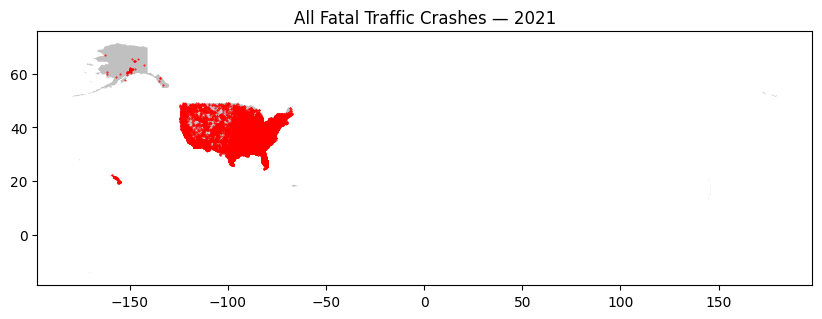

In [80]:
#plotting the two GeoPandas dataframes on one plot
fig, ax = plt.subplots(figsize=(10, 6))

states_gdf.plot(ax=ax, color='silver')
geo_df.plot(ax=ax, color='red', markersize=0.2)

ax.set_title('All Fatal Traffic Crashes — 2021')
plt.show()

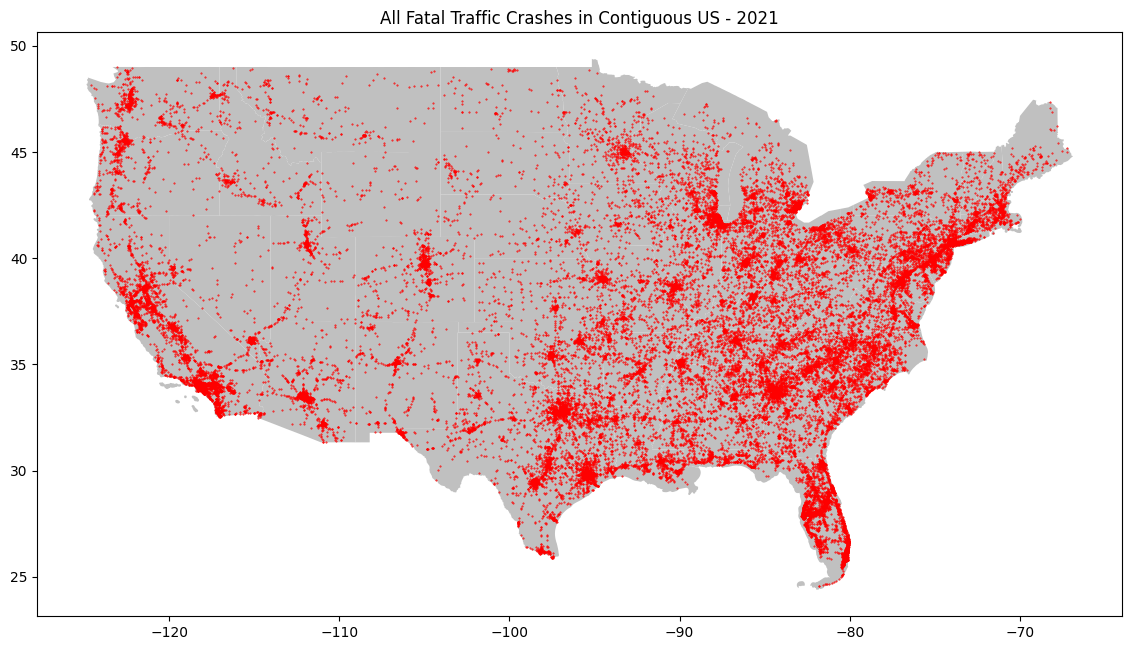

In [81]:
#plotting the crashes in only the contiguous US states
fig, ax = plt.subplots(figsize=(14, 8))

# Only showing contiguous states (excluding noncontiguous and territories)
to_exclude = ['Alaska', 'Hawaii', 'American Samoa', 'Guam','Commonwealth of the Northern Mariana Islands','Puerto Rico', 'United States Virgin Islands']

contiguous_states = states_gdf[~states_gdf['NAME'].isin(to_exclude)]

accidents = geo_df[~geo_df['STATENAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

# State (background)
contiguous_states.plot(ax=ax, color='silver')

# Crash points
accidents.plot(ax=ax, color='red', markersize=0.2)

# Title and output of the map
ax.set_title('All Fatal Traffic Crashes in Contiguous US - 2021')
plt.show()

2b) From the map of the contiguous United States, we can clearly identify places where there is a high density of fatal crashes. Some of these locations include Florida, California, Texas, and much of the Northeast. We also notice locations where many fatal crashes do not occur such as the midwest and great plains where there are very few cities. 

## Question 3

In [82]:
#using the sjoin to join the accidents and contiguous states dataframes
crash_joined = gpd.sjoin(accidents, contiguous_states,  how="inner", predicate='within')

In [83]:
#checking to make sure the correct column names are in the crash_join df
new_col = []
for c in crash_joined.columns:
  # Check if the column name is not already in `accidents.columns`
  if c not in accidents.columns:
    # append to new_col
    new_col.append(c)

print(f"Columns added: {new_col}")

Columns added: ['index_right', 'REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON']


In [84]:
#printing the head of the new joined dataframe
crash_joined.head()

,STATE,STATENAME,ST_CASE,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS,PVH_INVL,PERSONS,PERMVIT,...,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
0,1,Alabama,10001,0,0,2,2,0,3,3,...,01,AL,Alabama,00,G4000,A,131175477769,4591897964,+32.7396323,-086.8434593
1,1,Alabama,10002,0,0,1,1,0,2,2,...,01,AL,Alabama,00,G4000,A,131175477769,4591897964,+32.7396323,-086.8434593
2,1,Alabama,10003,1,1,1,1,0,1,1,...,01,AL,Alabama,00,G4000,A,131175477769,4591897964,+32.7396323,-086.8434593
3,1,Alabama,10004,0,0,1,1,0,1,1,...,01,AL,Alabama,00,G4000,A,131175477769,4591897964,+32.7396323,-086.8434593
4,1,Alabama,10005,0,0,2,2,0,4,4,...,01,AL,Alabama,00,G4000,A,131175477769,4591897964,+32.7396323,-086.8434593


In [85]:
#grouping the dataset by NAME column
crashes_per_state = (crash_joined.groupby('NAME').agg(crash_cnt=('ST_CASE', 'count'),
                                                      total_fatals=('FATALS', 'sum'),
                                                      land_area=('ALAND', 'first')).reset_index())

In [86]:
#printing the top 10 states by crash count
crashes_per_state.sort_values(by='crash_cnt', ascending=False).head(10)

,NAME,crash_cnt,total_fatals,land_area
41,Texas,4066,4495,676681550479
3,California,3970,4271,403671756816
8,Florida,3444,3731,138961722096
9,Georgia,1670,1797,149486624386
31,North Carolina,1525,1653,125933327733
33,Ohio,1242,1354,105823653399
40,Tennessee,1229,1327,106791957894
11,Illinois,1205,1329,143778561906
36,Pennsylvania,1152,1229,115881784866
38,South Carolina,1112,1198,77866200776


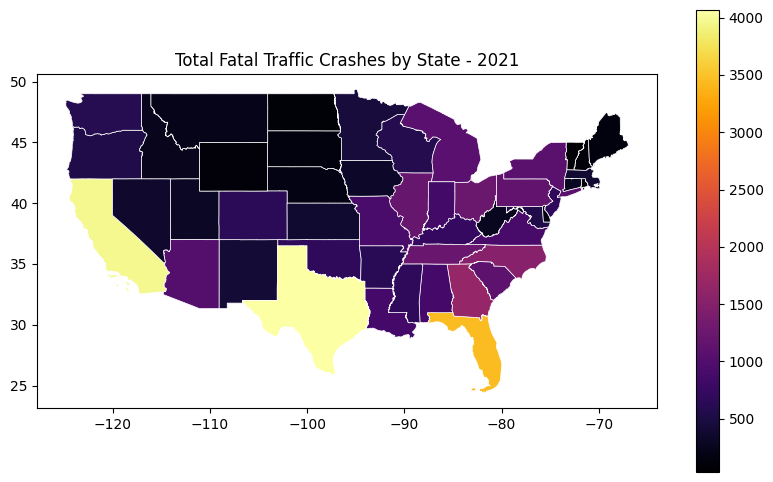

In [87]:
#creating a chloropleth map of the number of fatal crashes by states
# Merge statistics back with map shapes
states_with_stat = contiguous_states.merge(crashes_per_state, on='NAME', how='inner')

fig, ax = plt.subplots(figsize=(10, 6))

# Plot choropleth
states_with_stat.plot(column='crash_cnt', cmap='inferno', ax=ax, legend=True,edgecolor='white', linewidth=0.5)

# Map output
ax.set_title('Total Fatal Traffic Crashes by State - 2021')
plt.show()

3b) From my understanding, we obtained crash_joined by keeping all of the data from the accidents data set, and then joining it on the data that is common contiguous states data but the point from the accidents data set must be within the boundaries of the polygon created by the contiguous states dataset. This data includes additional geographic data that could be useful in identifying more local information about where the crashes occurred including whether it was near water, rural areas, or urban areas among others. From printing the head of the data, I notice that the INTPTLON column contains negative values, while the ALAND and AWATER columns contain large integer values.  

3c) The chloropleth map shows the states with higher numbers of fatal crashes. The states with the highest number of fatal crashes are Texas, California, and Florida, which makes sense because they have higher populations. It also shows that midwest states such as Iowa, Nebraska, Kansas, etc do not have many fatal accidents because their populations are not as high.  

## Question 4

In [88]:
# converting squre meters to sq kilometers
crashes_per_state['land_area_sqkm'] = crashes_per_state['land_area'] / 1000000

In [89]:
# calculating the crashes per 1000 sq km
crashes_per_state['crash_density'] = (crashes_per_state['crash_cnt'] / crashes_per_state['land_area_sqkm']) * 1000

In [90]:
#finding the top 10 crash counts
print("Top 10 States for Crash Count")
crashes_per_state.sort_values(by='crash_cnt', ascending=False).head(10)

Top 10 States for Crash Count


,NAME,crash_cnt,total_fatals,land_area,land_area_sqkm,crash_density
41,Texas,4066,4495,676681550479,676681.550479,6.008735
3,California,3970,4271,403671756816,403671.756816,9.834723
8,Florida,3444,3731,138961722096,138961.722096,24.783803
9,Georgia,1670,1797,149486624386,149486.624386,11.171568
31,North Carolina,1525,1653,125933327733,125933.327733,12.109582
33,Ohio,1242,1354,105823653399,105823.653399,11.736507
40,Tennessee,1229,1327,106791957894,106791.957894,11.508357
11,Illinois,1205,1329,143778561906,143778.561906,8.380943
36,Pennsylvania,1152,1229,115881784866,115881.784866,9.941165
38,South Carolina,1112,1198,77866200776,77866.200776,14.280907


In [91]:
#finding the top 10 crash counts for density
print("\n Top 10 States for Crash Count - Density (per 1000 sq km)")
crashes_per_state.sort_values(by='crash_density', ascending=False).head(10)


 Top 10 States for Crash Count - Density (per 1000 sq km)


,NAME,crash_cnt,total_fatals,land_area,land_area_sqkm,crash_density
7,District of Columbia,36,37,158316124,158.316124,227.393137
28,New Jersey,667,697,19048916230,19048.916230,35.015115
6,Delaware,131,135,5046731559,5046.731559,25.957394
8,Florida,3444,3731,138961722096,138961.722096,24.783803
5,Connecticut,283,298,12541690473,12541.690473,22.564741
37,Rhode Island,60,62,2677763359,2677.763359,22.406760
18,Maryland,526,565,25151992308,25151.992308,20.912856
19,Massachusetts,397,417,20204390225,20204.390225,19.649195
38,South Carolina,1112,1198,77866200776,77866.200776,14.280907
31,North Carolina,1525,1653,125933327733,125933.327733,12.109582


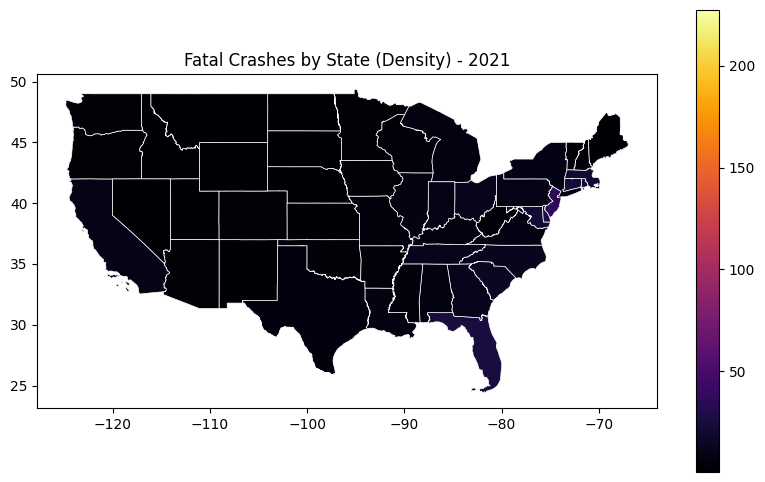

In [92]:
#creating a chloropleth map of the density crash counts
# Merge with map shapes (crashes_per_state)
density_map = contiguous_states.merge(crashes_per_state, on='NAME', how='inner')

fig, ax = plt.subplots(figsize=(10,6))

density_map.plot(column='crash_density', ax=ax, cmap='inferno', legend=True, edgecolor='white', linewidth=0.5)

# Map output with label/title
ax.set_title("Fatal Crashes by State (Density) - 2021")
plt.show()

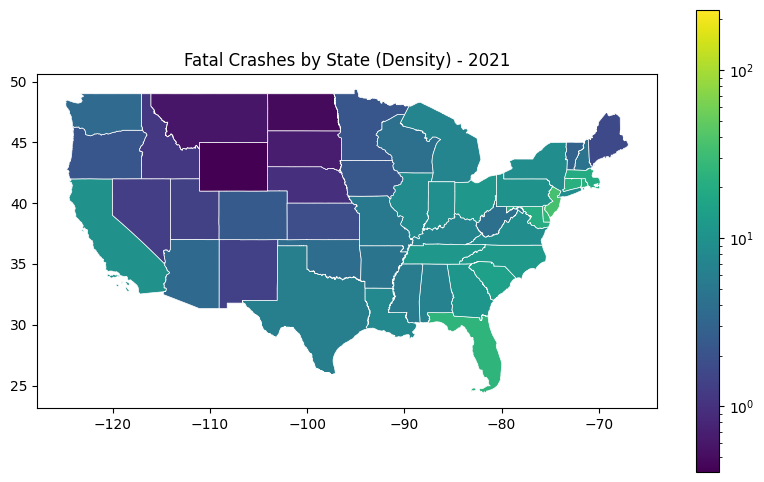

In [93]:
#using a log scale to fix the visualization

fig_2, ax_2 = plt.subplots(figsize=(10,6))

density_map.plot(column='crash_density', ax=ax_2, legend=True, edgecolor='white', linewidth=0.5, norm=plt.matplotlib.colors.LogNorm())

# Map output with label/title
ax_2.set_title("Fatal Crashes by State (Density) - 2021")
plt.show()

4b) Washington D.C. has interesting results as it has the highest number of fatal accidents per 1000 square kilometers. It's density value was about 230 which was significantly larger than any of the other density scores. This is in large part because D.C. has a large population in a small piece of land, so the number of fatal crashes per 1000 square kilometers is so much larger than any of the other states that have population spread out over a larger amount of land.

4c) The results of the density chloropleth map can definitely change spatial interpretation of fatal crashes across states because states that are much smaller, but with larger populations such as New Jersey, Massachusetts, etc have higher densities than larger states. As a result, we see that more crashes on average happen within a 1000 square kilometer radius because the large populations result in many crashes within a smaller radius as compared to fatal crashes without considering a distance boundary. 

## Question 5

In [94]:
#looking at Indiana crashes only 
indiana_crashes = accidents[accidents['STATENAME'] == 'Indiana'].copy()
# Indiana only state boundary
indiana_boundary = contiguous_states[contiguous_states['NAME'] == 'Indiana']

# Number of crashes in indiana_crashes
print(f"Number of fatal crashes in Indiana (2021): {len(indiana_crashes)}")

# Description of what we are printing below
print("We are printing the number of crashes in only Indiana and then focusing on whether they occurred in rural or urban areas")

# Rural and Urban crashes counts
indiana_crashes["RUR_URB"].value_counts()

Number of fatal crashes in Indiana (2021): 861
We are printing the number of crashes in only Indiana and then focusing on whether they occurred in rural or urban areas


RUR_URB
2    479
1    381
6      1
Name: count, dtype: int64

<Axes: >

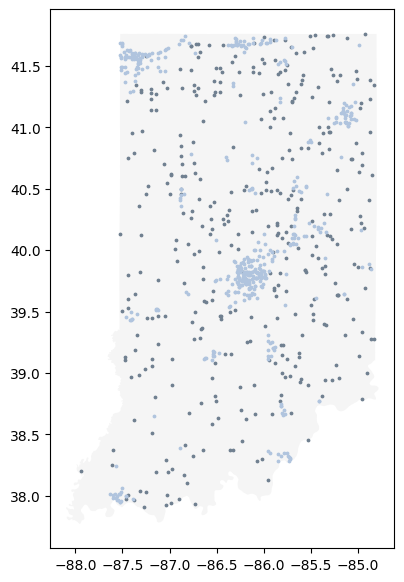

In [95]:
#plotting rural vs. urban crashes on a map
fig, ax = plt.subplots(figsize=(8, 7))

# Put indiana state boundary as the background
indiana_boundary.plot(ax=ax, color='whitesmoke')

# Crashes by rural & urban + different colours
rural = indiana_crashes[indiana_crashes['RUR_URB'] == 1]
urban = indiana_crashes[indiana_crashes['RUR_URB'] == 2]

rural.plot(ax=ax, color='slategrey', markersize=3, label='Rural')
urban.plot(ax=ax, color='lightsteelblue', markersize=3, label='Urban')

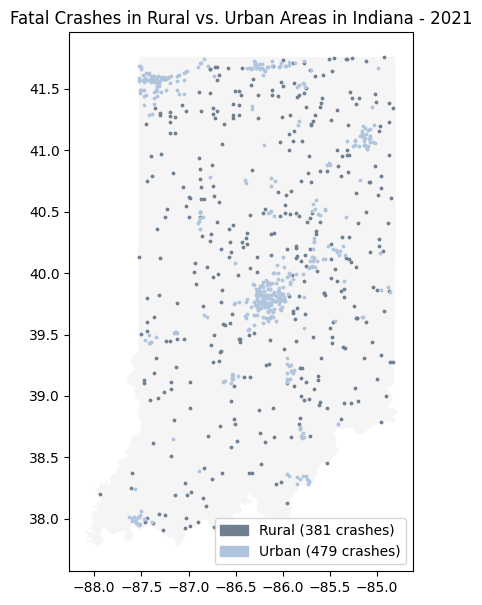

In [96]:
#manually adding a legend to the map
import matplotlib.patches as mpatches

#plotting rural vs. urban crashes on a map
fig, ax = plt.subplots(figsize=(8, 7))

# Legend
legend_elements = [mpatches.Patch(color='slategrey', label=f'Rural ({len(rural)} crashes)'),
                   mpatches.Patch(color='lightsteelblue', label=f'Urban ({len(urban)} crashes)')]

ax.legend(handles=legend_elements)

# Put indiana state boundary as the background
indiana_boundary.plot(ax=ax, color='whitesmoke')

# Crashes by rural & urban + different colours
rural = indiana_crashes[indiana_crashes['RUR_URB'] == 1]
urban = indiana_crashes[indiana_crashes['RUR_URB'] == 2]

rural.plot(ax=ax, color='slategrey', markersize=3, label='Rural')
urban.plot(ax=ax, color='lightsteelblue', markersize=3, label='Urban')

# Map output with label/title
ax.set_title('Fatal Crashes in Rural vs. Urban Areas in Indiana - 2021')
plt.show()

In [97]:
indiana_crashes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 861 entries, 14383 to 15245
Data columns (total 81 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   STATE         861 non-null    int64   
 1   STATENAME     861 non-null    object  
 2   ST_CASE       861 non-null    int64   
 3   PEDS          861 non-null    int64   
 4   PERNOTMVIT    861 non-null    int64   
 5   VE_TOTAL      861 non-null    int64   
 6   VE_FORMS      861 non-null    int64   
 7   PVH_INVL      861 non-null    int64   
 8   PERSONS       861 non-null    int64   
 9   PERMVIT       861 non-null    int64   
 10  COUNTY        861 non-null    int64   
 11  COUNTYNAME    861 non-null    object  
 12  CITY          861 non-null    int64   
 13  CITYNAME      861 non-null    object  
 14  MONTH         861 non-null    int64   
 15  MONTHNAME     861 non-null    object  
 16  DAY           861 non-null    int64   
 17  DAYNAME       861 non-null    int64   
 18  D

In [98]:
#comparing the fatality rates between the different environments
rural_fatal = indiana_crashes[indiana_crashes['RUR_URB'] == 1]['FATALS'].mean()
urban_fatal = indiana_crashes[indiana_crashes['RUR_URB'] == 2]['FATALS'].mean()

print(f"Average fatalities (rural): {rural_fatal}")
print(f"Average fatalities (urban): {urban_fatal}")

Average fatalities (rural): 1.1128608923884515
Average fatalities (urban): 1.0542797494780793


In [100]:
#printing all the unique values in the 'REGION' column
print(states_gdf['REGION'].unique())

['3' '2' '1' '4' '9']


In [101]:
#merging the contiguous states data with the crashes data
states_region = contiguous_states.merge(crashes_per_state, on='NAME', how='left')

In [102]:
#recoding that states' regions with labels instead of numerals
region_names = {'1': 'Northeast', '2': 'Midwest', '3': 'South', '4': 'West'}
states_region['REGION_NAME'] = states_region['REGION'].map(region_names)

In [103]:
#printing the head of REGION_NAME col
states_region['REGION_NAME'].head()

0      South
1      South
2    Midwest
3    Midwest
4      South
Name: REGION_NAME, dtype: object

In [104]:
#grouping the states by geometry using the .dissolve function
regions_gdf = states_region.dissolve(by='REGION_NAME',
                                       aggfunc={'crash_cnt': 'sum',
                                                'total_fatals': 'sum',
                                                'land_area': 'sum'}).reset_index()

In [105]:
#printing regions_gdf
print(regions_gdf)

  REGION_NAME                                           geometry  crash_cnt  \
0     Midwest  POLYGON ((-98.34819 36.99815, -98.34874 36.998...       7454   
1   Northeast  MULTIPOLYGON (((-74.48282 39.28414, -74.48695 ...       3949   
2       South  MULTIPOLYGON (((-80.18532 25.33851, -80.18697 ...      19394   
3        West  MULTIPOLYGON (((-118.65436 33.07495, -118.6413...       8423   

   total_fatals      land_area  
0          8126  1943991852468  
1          4185   419354636236  
2         21156  2249835530078  
3          9169  3041775201247  


In [107]:
# normalizing the data for improved visualizations
# Convert land area from sq m to sq km
regions_gdf['land_area_sqkm'] = regions_gdf['land_area'] / 1000000

# Calculate density with (total crashes/total area) * 1000
regions_gdf['crash_density'] = (regions_gdf['crash_cnt'] / regions_gdf['land_area_sqkm']) * 1000

# Print result highest to lowest
print(f"Most crashes (base): {regions_gdf.sort_values(by='crash_cnt', ascending=False)}")
print(f"Most crashes (density) {regions_gdf.sort_values(by='crash_density', ascending=False)}")

Most crashes (base):   REGION_NAME                                           geometry  crash_cnt  \
2       South  MULTIPOLYGON (((-80.18532 25.33851, -80.18697 ...      19394   
3        West  MULTIPOLYGON (((-118.65436 33.07495, -118.6413...       8423   
0     Midwest  POLYGON ((-98.34819 36.99815, -98.34874 36.998...       7454   
1   Northeast  MULTIPOLYGON (((-74.48282 39.28414, -74.48695 ...       3949   

   total_fatals      land_area  land_area_sqkm  crash_density  
2         21156  2249835530078    2.249836e+06       8.620186  
3          9169  3041775201247    3.041775e+06       2.769107  
0          8126  1943991852468    1.943992e+06       3.834378  
1          4185   419354636236    4.193546e+05       9.416851  
Most crashes (density)   REGION_NAME                                           geometry  crash_cnt  \
1   Northeast  MULTIPOLYGON (((-74.48282 39.28414, -74.48695 ...       3949   
2       South  MULTIPOLYGON (((-80.18532 25.33851, -80.18697 ...      19394   
0  

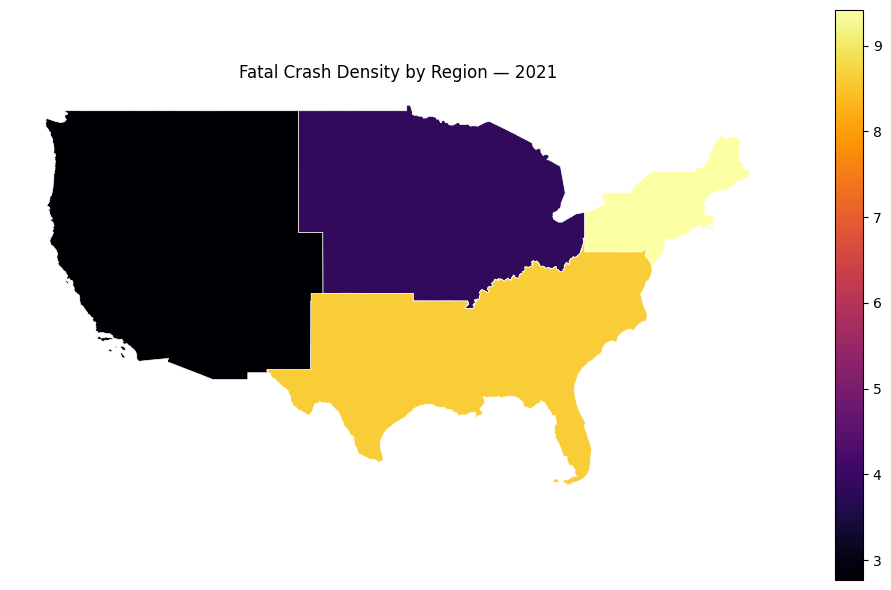

In [108]:
#printing the regional chloropleth map
fig, ax = plt.subplots(figsize=(10,6))

regions_gdf.plot(column='crash_density', cmap='inferno', ax=ax, legend=True, edgecolor='white', linewidth=0.5)

ax.set_title('Fatal Crash Density by Region — 2021')
ax.set_axis_off()
plt.tight_layout()
plt.show()

5b) One difference I notice between the rural and urban maps is that most of the urban crashes are clustered in the urban areas within the cities, while the rural areas are spread out throughout the state. It is also interesting to see how almost 500 urban crashes in just 2-3 clusters, while there about 400 rural crashes just spread out throughout the state without any real clusters at all. This is in large part because of the population densities of the areas. There are more people and therefore more roads and highways for there to be accidents on in urban areas than in rural areas. I definitely think it is related to fatality rates because more highways means higher speeds and higher likelihood of a fatality if there were a collision. 

5c) By printing the regions_gdf dataframe, we get information about each regions's latitude and longitude boundaries, as well as the total area of the region, number of fatalities, number of crashes. From this we could calculate the average number of fatalities per x square km or the number of fatalities per crash, among others.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
